In [57]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [58]:
import tensorflow_hub as hub

# Load model (SSD MobileNet)
model = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2")
print("Model loaded successfully!")
#model = hub.load("https://tfhub.dev/tensorflow/centernet/hourglass_512x512/1")
#model = hub.load("https://www.kaggle.com/models/tensorflow/faster-rcnn-inception-resnet-v2/TensorFlow2/1024x1024/1")

Model loaded successfully!


In [65]:
# -----------------------------
# 2️⃣ Define COCO class labels (subset for simplicity)
# -----------------------------
coco_labels = {
    1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane',
    6: 'bus', 7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light',
    11: 'fire hydrant', 13: 'stop sign', 14: 'parking meter', 15: 'bench',
    16: 'bird', 17: 'cat', 18: 'dog', 19: 'horse', 20: 'sheep',
    21: 'cow', 22: 'elephant', 23: 'bear', 24: 'zebra', 25: 'giraffe',
    27: 'backpack', 28: 'umbrella', 31: 'handbag', 32: 'tie', 33: 'suitcase',
    34: 'frisbee', 35: 'skis', 36: 'snowboard', 37: 'sports ball', 38: 'kite',
    39: 'baseball bat', 40: 'baseball glove', 41: 'skateboard', 42: 'surfboard', 43: 'tennis racket',
    44: 'bottle', 46: 'wine glass', 47: 'cup', 48: 'fork', 49: 'knife',
    50: 'spoon', 51: 'bowl', 52: 'banana', 53: 'apple', 54: 'sandwich',
    55: 'orange', 56: 'broccoli', 57: 'carrot', 58: 'hot dog', 59: 'pizza',
    60: 'donut', 61: 'cake', 62: 'chair', 63: 'couch', 64: 'potted plant',
    65: 'bed', 67: 'dining table', 70: 'toilet', 72: 'tv', 73: 'laptop',
    74: 'mouse', 75: 'remote', 76: 'keyboard', 77: 'cell phone', 78: 'microwave',
    79: 'oven', 80: 'toaster', 81: 'sink', 82: 'refrigerator', 84: 'book',
    85: 'clock', 86: 'vase', 87: 'scissors', 88: 'teddy bear', 89: 'hair drier',
    90: 'toothbrush'
}


In [79]:
# -----------------------------
# 3️⃣ Load your image
# -----------------------------
image_path = r"images\000000000428.jpg"  # replace with your image path
image = cv2.imread(image_path)

# Check if image loaded correctly
if image is None:
    raise ValueError("Image not found. Check the file path!")

# Convert BGR (OpenCV default) to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [80]:

# -----------------------------
# 4️⃣ Prepare image for the model
# -----------------------------
# Convert to float32 tensor and add batch dimension
input_tensor = tf.convert_to_tensor(image_rgb, dtype=tf.uint8)
input_tensor = tf.expand_dims(input_tensor, axis=0)  # shape: [1, height, width, 3]

In [81]:
# -----------------------------
# 5️⃣ Run object detection
# -----------------------------
output = model(input_tensor)

# Extract detection results
boxes = output['detection_boxes'][0].numpy()        # Bounding boxes
scores = output['detection_scores'][0].numpy()      # Confidence scores
classes = output['detection_classes'][0].numpy()    # Class IDs

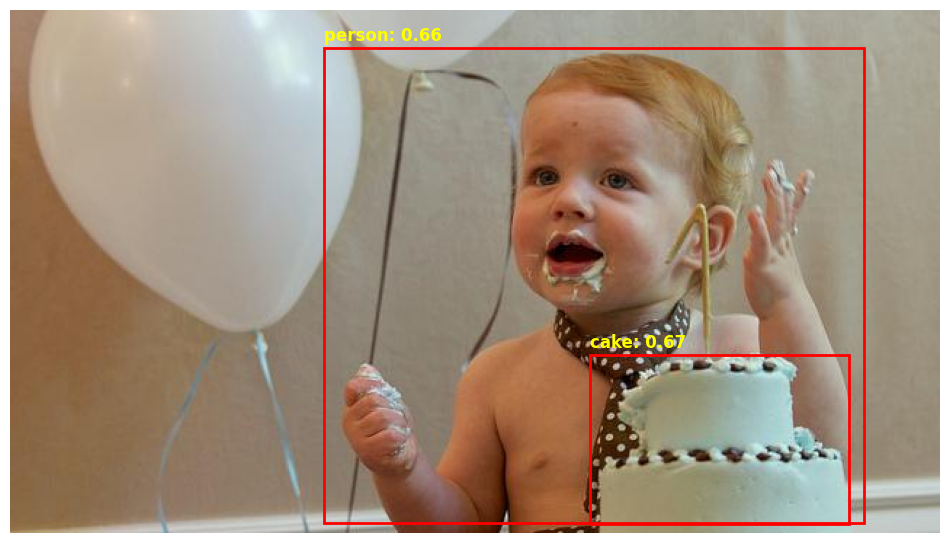

In [82]:
# -----------------------------
# 6️⃣ Visualize results
# -----------------------------
plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
ax = plt.gca()

height, width, _ = image_rgb.shape

for i in range(len(boxes)):
    if scores[i] >= 0.5:  # Only show predictions with confidence >= 0.5
        class_id = int(classes[i])
        class_name = coco_labels.get(class_id, 'N/A')
        ymin, xmin, ymax, xmax = boxes[i]

        # Scale box coordinates to image size
        (left, top, right, bottom) = (xmin*width, ymin*height, xmax*width, ymax*height)

        # Draw bounding box
        rect = plt.Rectangle((left, top), right-left, bottom-top,
                             fill=False, color='red', linewidth=2)
        ax.add_patch(rect)

        # Draw class label + confidence
        ax.text(left, top-5, f"{class_name}: {scores[i]:.2f}",
                color='yellow', fontsize=12, weight='bold')

plt.axis('off')
plt.show()